<a href="https://colab.research.google.com/github/mustaphaelansary7-rgb/mostafa-data-analysis/blob/main/Copy_of_HealthCare_Mostafa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importing Data
raw_data=pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

In [ ]:
data=raw_data.copy()
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
def draw_missing_data_table(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent = (data.isnull().sum()/data.isnull().count()).sort_values(ascending=False)
    missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
    return missing_data
draw_missing_data_table(data)

,Total,Percent
bmi,201,0.039335
id,0,0.000000
age,0,0.000000
gender,0,0.000000
hypertension,0,0.000000
heart_disease,0,0.000000
work_type,0,0.000000
ever_married,0,0.000000
Residence_type,0,0.000000
avg_glucose_level,0,0.000000


In [ ]:
# Imputing the missing values with the mean
data=data.fillna(np.mean(data['bmi']))

In [ ]:
# Classifying data into numerical and categorical variables.
data_numerical=data[['age','avg_glucose_level','bmi']]
data_categorical=data[['gender', 'hypertension', 'heart_disease', 'ever_married','work_type', 'Residence_type',
                       'smoking_status', 'stroke']]

Text(0.5, 1.0, 'Kde Plots for age, avg_glucose_level and bmi')

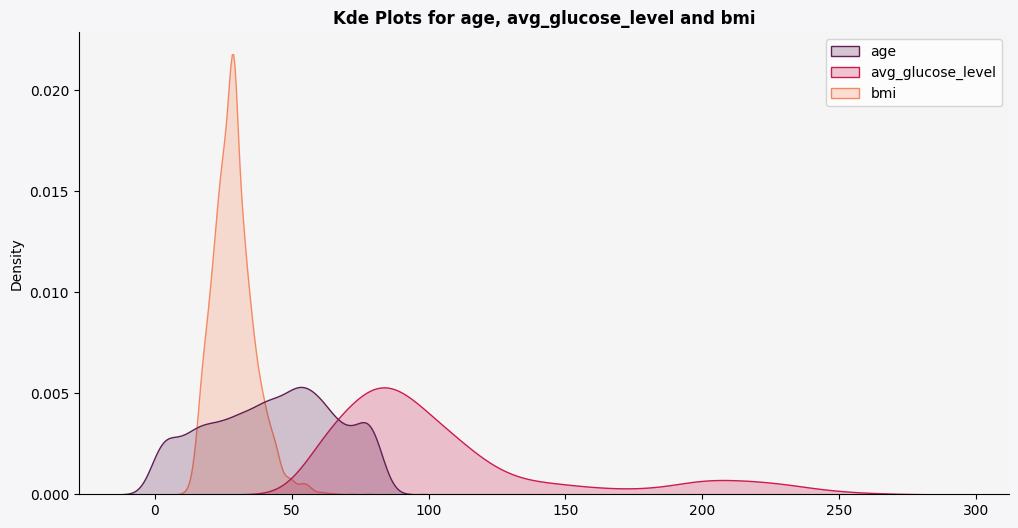

In [ ]:
fig, ax = plt.subplots(figsize = (12,6))
fig.patch.set_facecolor('#f6f5f7')
ax.set_facecolor('#f6f5f5')
sns.kdeplot(data=data_numerical,shade=True,palette='rocket') # Distributions
# removing spines
for i in ["top","right"]:
    ax.spines[i].set_visible(False)
plt.title('Kde Plots for age, avg_glucose_level and bmi',weight='bold')

<Axes: xlabel='avg_glucose_level', ylabel='Density'>

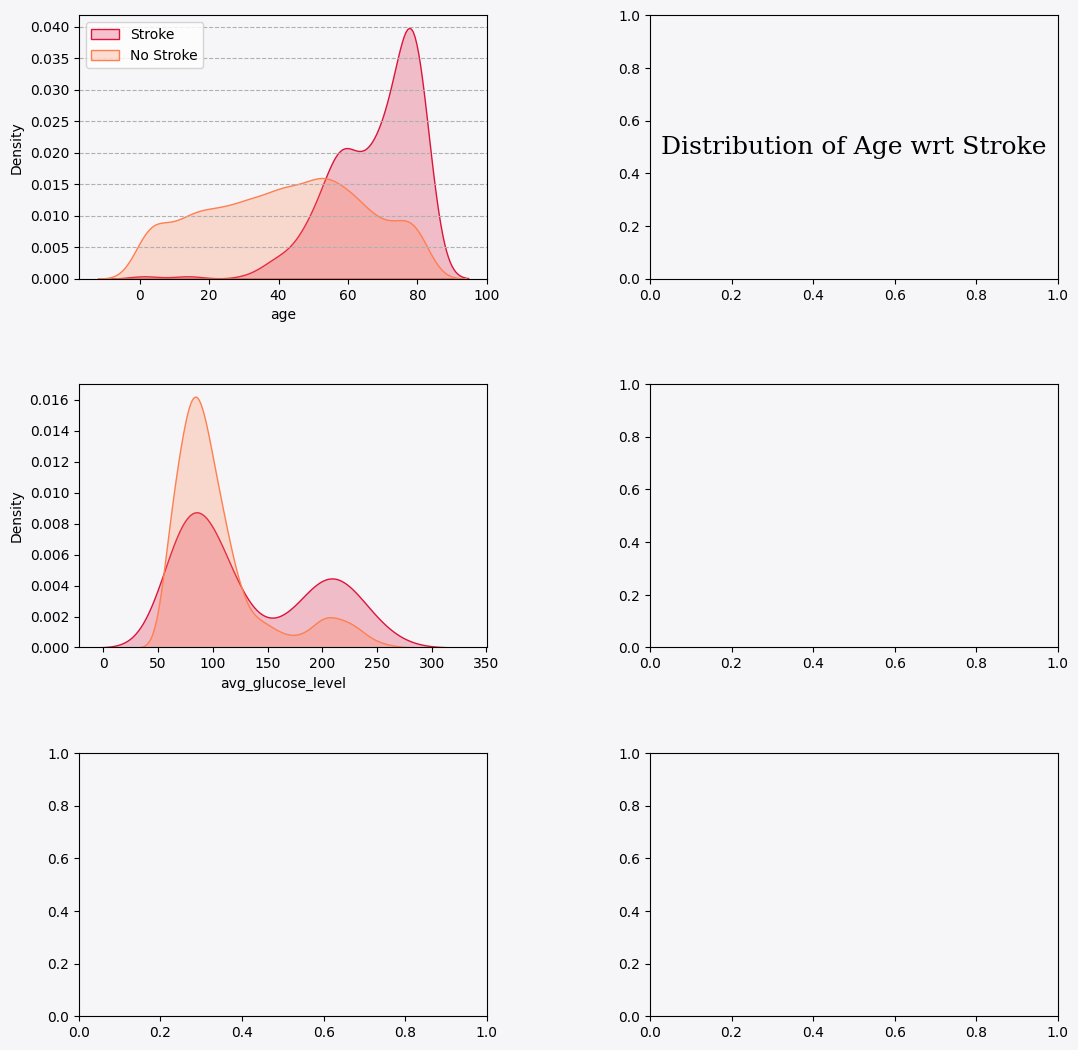

In [ ]:
fig = plt.figure(figsize=(20,13))
gs = fig.add_gridspec(3,3)
gs.update(wspace=0.4, hspace=0.4)
# adding figures
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[1,0])
ax3 = fig.add_subplot(gs[1,1])
ax4 = fig.add_subplot(gs[2,0])
ax5 = fig.add_subplot(gs[2,1])
axes=[ax0,ax1,ax2,ax3,ax4,ax5]
background_color = '#f6f5f7'
for i in axes:
    i.set_facecolor(background_color)
fig.patch.set_facecolor(background_color)
#https://www.geeksforgeeks.org/kde-plot-visualization-with-pandas-and-seaborn/
sns.kdeplot(ax=ax0,x=data.loc[data['stroke']==1]['age'],color='crimson',label='Stroke',shade=True)
sns.kdeplot(ax=ax0,x=data.loc[data['stroke']==0]['age'],color='coral',label='No Stroke',shade=True)
ax0.legend(loc = 'upper left')
ax0.grid(linestyle='--', axis='y')

ax1.text(0.5,0.5,'Distribution of Age wrt Stroke',horizontalalignment = 'center',verticalalignment = 'center',fontsize = 18,fontfamily='serif')

sns.kdeplot(ax=ax2,x=data.loc[data['stroke']==1]['avg_glucose_level'],color='crimson',label='Stroke',shade=True)
sns.kdeplot(ax=ax2,x=data.loc[data['stroke']==0]['avg_glucose_level'],color='coral',label='No Stroke',shade=True)

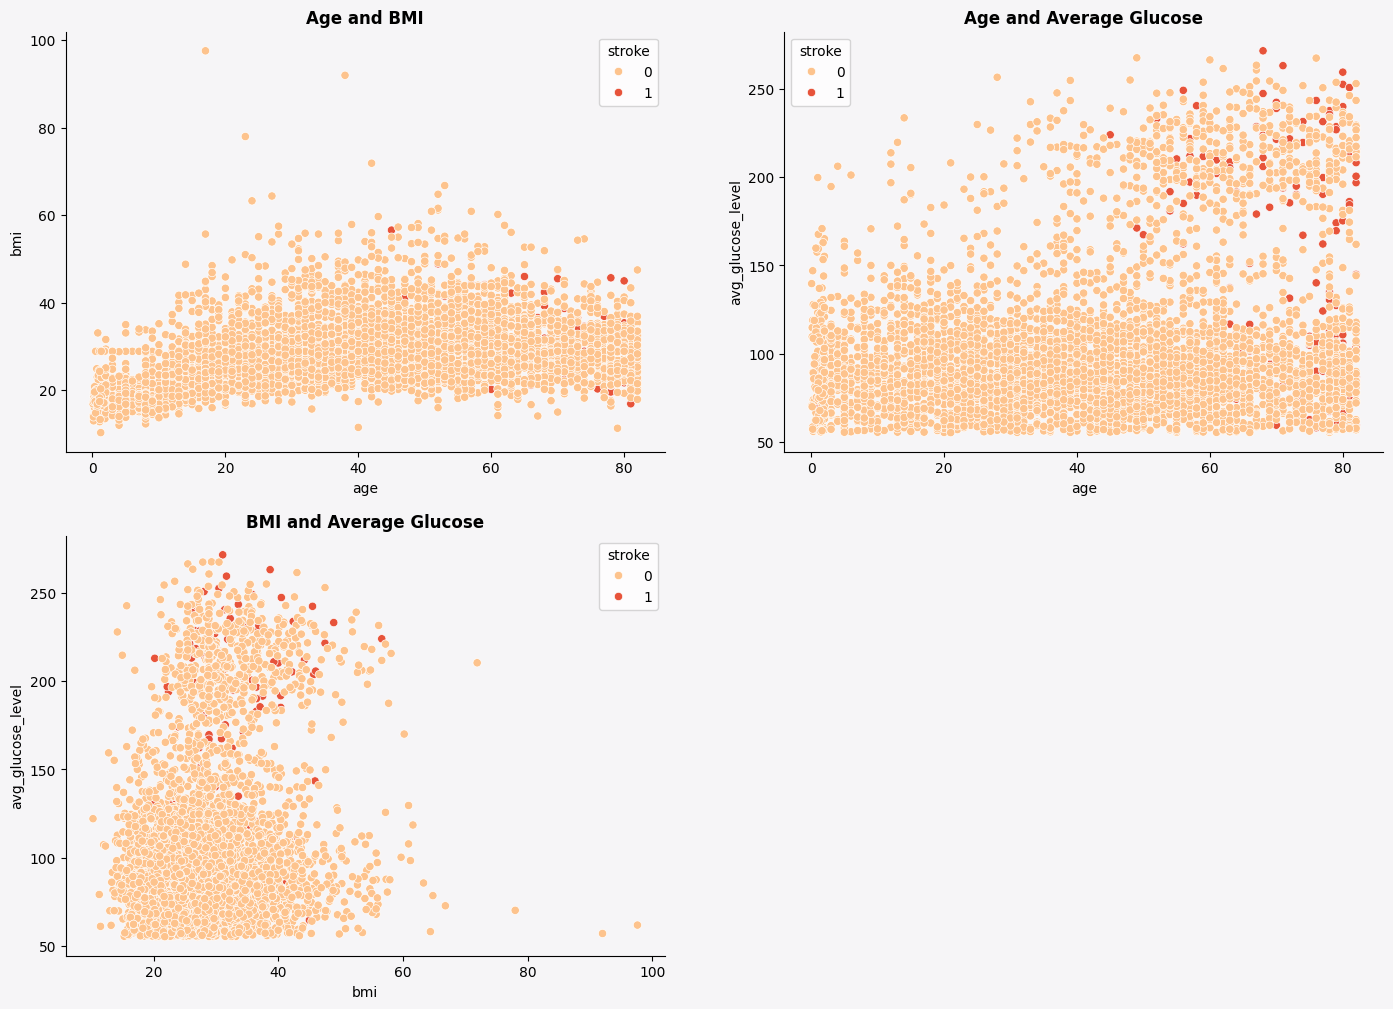

In [ ]:
fig = plt.figure(figsize=(17,12))
gs = fig.add_gridspec(2,2)
ax0=fig.add_subplot(gs[0,0])
ax1=fig.add_subplot(gs[0,1])
ax2=fig.add_subplot(gs[1,0])
axes=[ax0,ax1,ax2]
background_color = '#f6f5f7'
for i in axes:
    i.set_facecolor(background_color)
fig.patch.set_facecolor(background_color)
# Age and bmi
sns.scatterplot(ax=ax0,x=data_numerical['age'],y=data_numerical['bmi'],hue=data_categorical['stroke'],palette="OrRd")
ax0.set_title('Age and BMI',fontweight='bold')
# Age and Glucose
sns.scatterplot(ax=ax1,x=data_numerical['age'],y=data_numerical['avg_glucose_level'],hue=data_categorical['stroke'],palette="OrRd")
ax1.set_title('Age and Average Glucose',fontweight='bold')
# BMI and Glucose
sns.scatterplot(ax=ax2,x=data_numerical['bmi'],y=data_numerical['avg_glucose_level'],hue=data_categorical['stroke'],palette="OrRd")
ax2.set_title('BMI and Average Glucose',fontweight='bold')
#removing spines
for i in ["top","right"]:
    ax0.spines[i].set_visible(False)
    ax1.spines[i].set_visible(False)
    ax2.spines[i].set_visible(False)

Text(-1.7, 1.1, 'Heatmap of Numerical Variables')

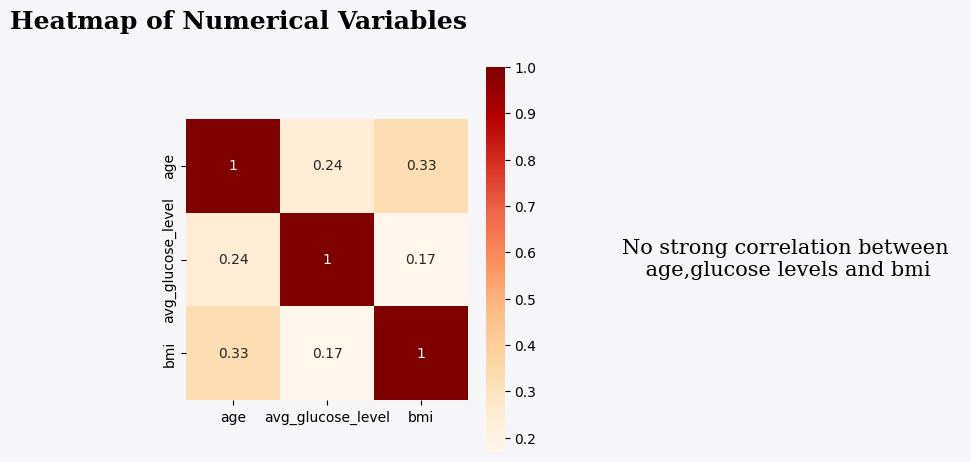

In [ ]:
fig=plt.figure(figsize=(10,5),dpi=100)
gs=fig.add_gridspec(1,2)
# adding subplots
ax0=fig.add_subplot(gs[0,0])
ax1=fig.add_subplot(gs[0,1])
axes=[ax0,ax1]
background_color = '#f6f5f7'
# changing background color of our plots
for i in axes:
    i.set_facecolor(background_color)
# changing the figure background color
fig.patch.set_facecolor(background_color)
# heatmap of numerical data
corrmat = data_numerical.corr()
sns.heatmap(ax=ax0,data=corrmat,annot=True, cmap="OrRd",square=True)
ax1.text(0.5,0.5,'No strong correlation between\n age,glucose levels and bmi',horizontalalignment = 'center',verticalalignment = 'center',fontsize = 15,fontfamily='serif')
ax1.spines["bottom"].set_visible(False)
ax1.spines["left"].set_visible(False)
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.tick_params(left=False, bottom=False)
for i in ["top","right","bottom","left"]:
    ax1.spines[i].set_visible(False)
plt.text(-1.7,1.1,'Heatmap of Numerical Variables',fontsize=18,fontweight='bold',fontfamily='serif')

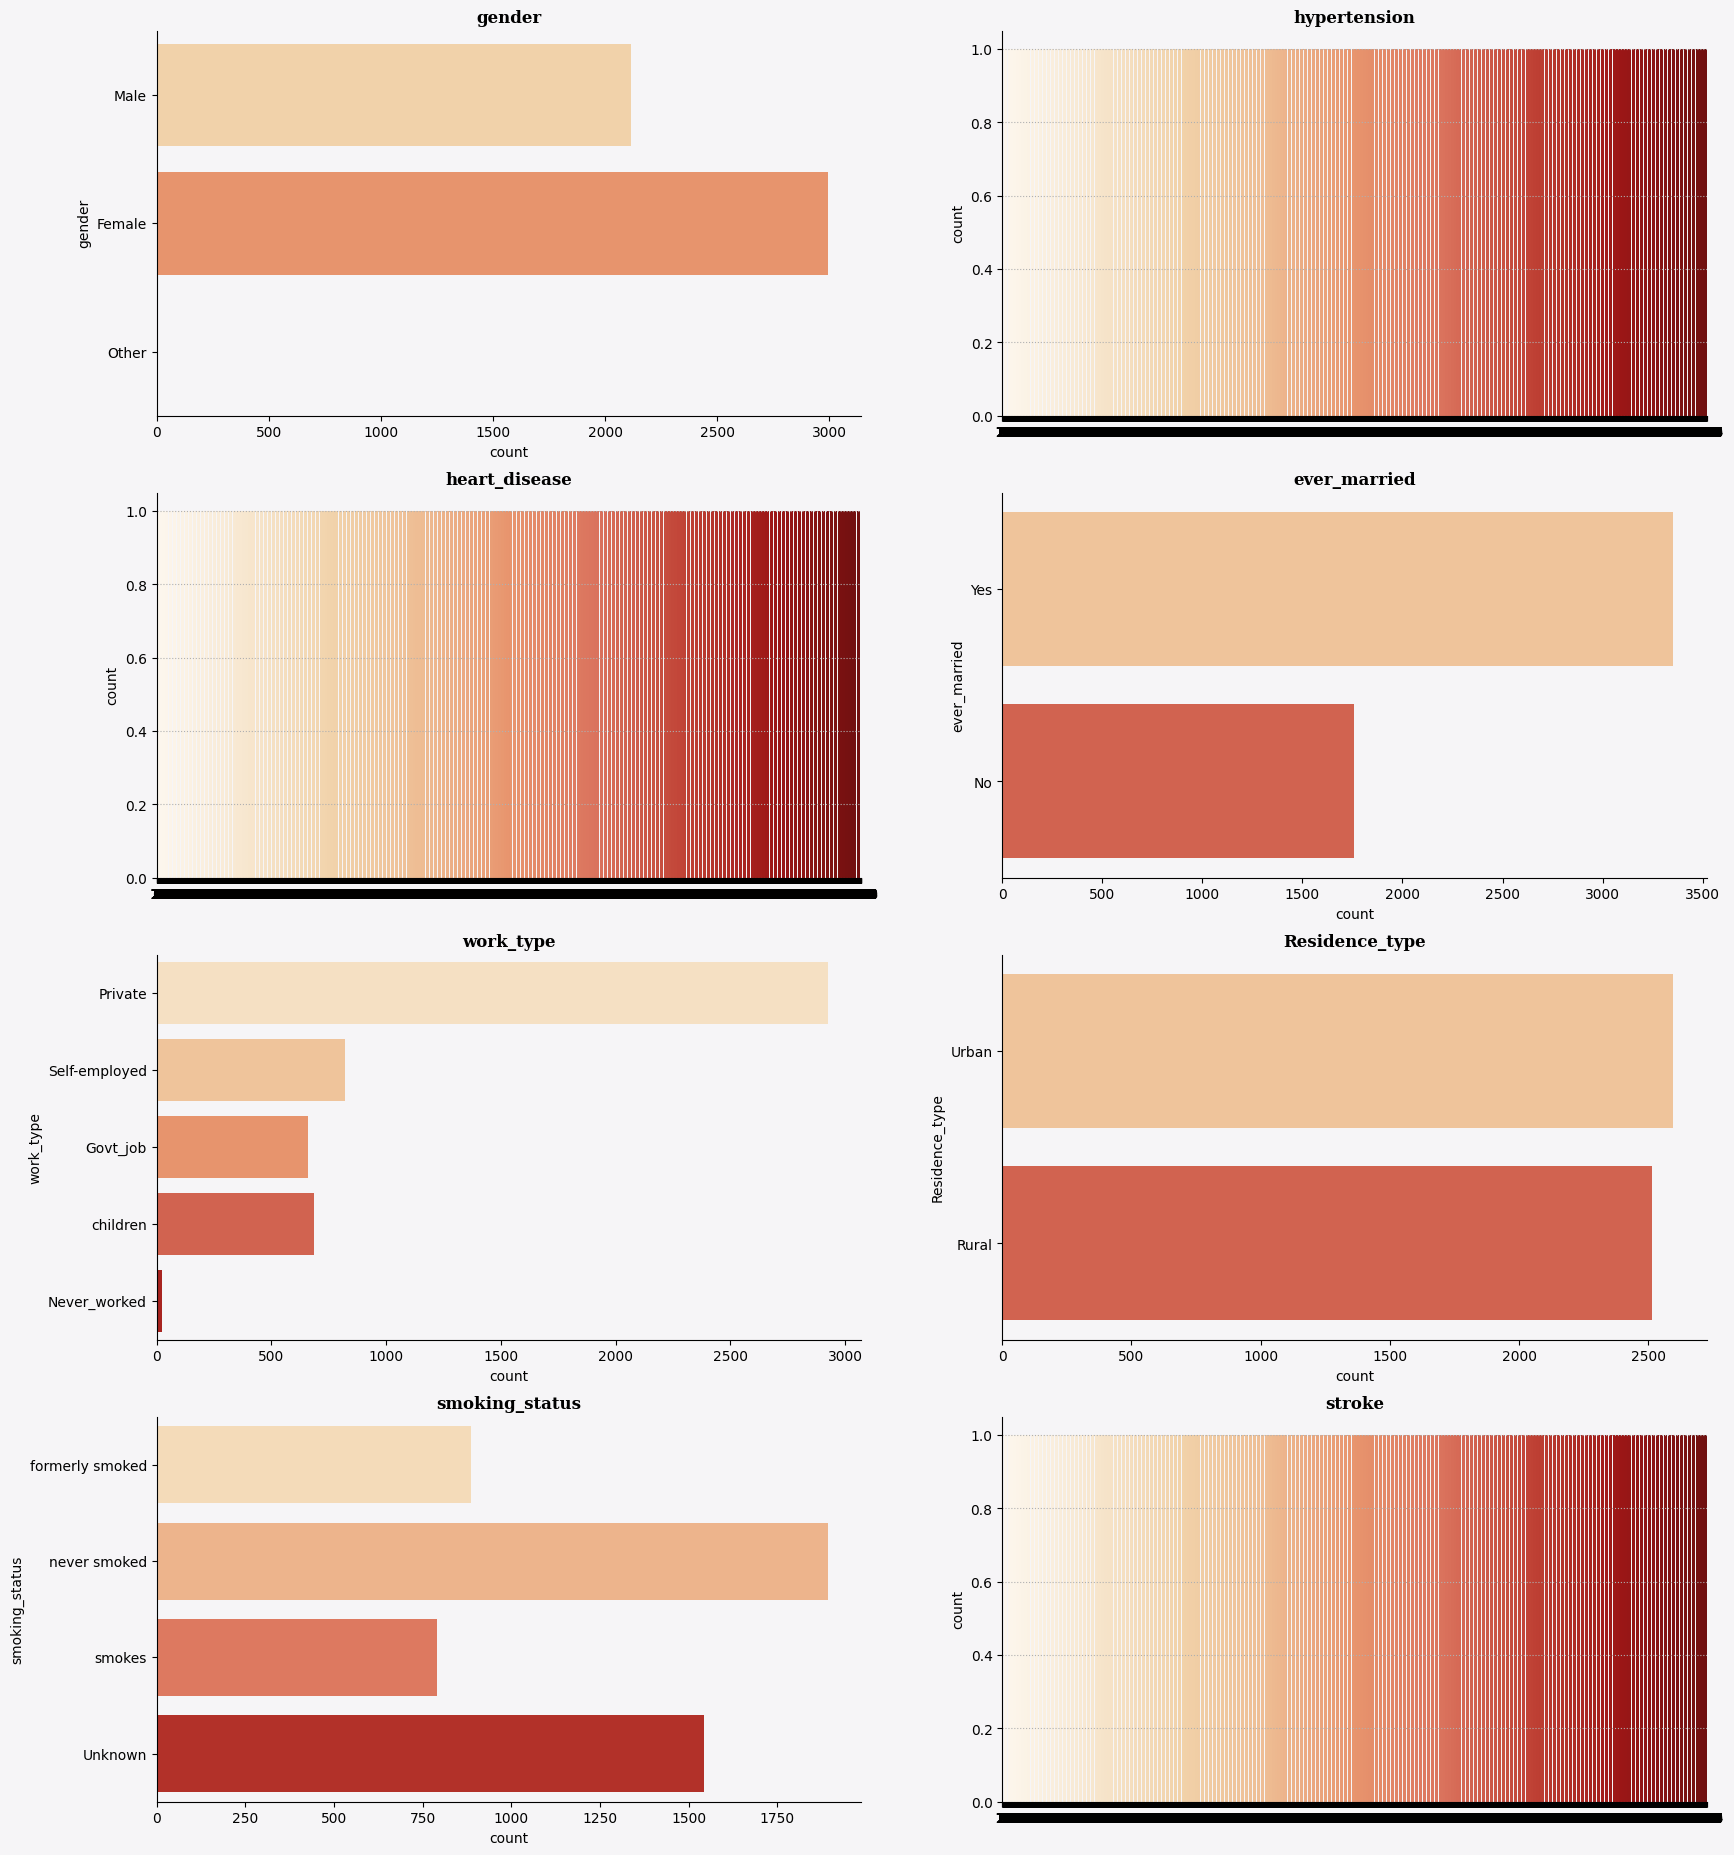

In [ ]:
fig=plt.figure(figsize=(20,23))
background_color = '#f6f5f7'
fig.patch.set_facecolor(background_color)
for indx,val in enumerate(data_categorical.columns):
    ax=plt.subplot(4,2,indx+1)
    ax.set_facecolor(background_color)
    ax.set_title(val,fontweight='bold',fontfamily='serif')
    for i in ['top','right']:
        ax.spines[i].set_visible(False)
    ax.grid(linestyle=':',axis='y')
    sns.countplot(data_categorical[val],palette='OrRd')

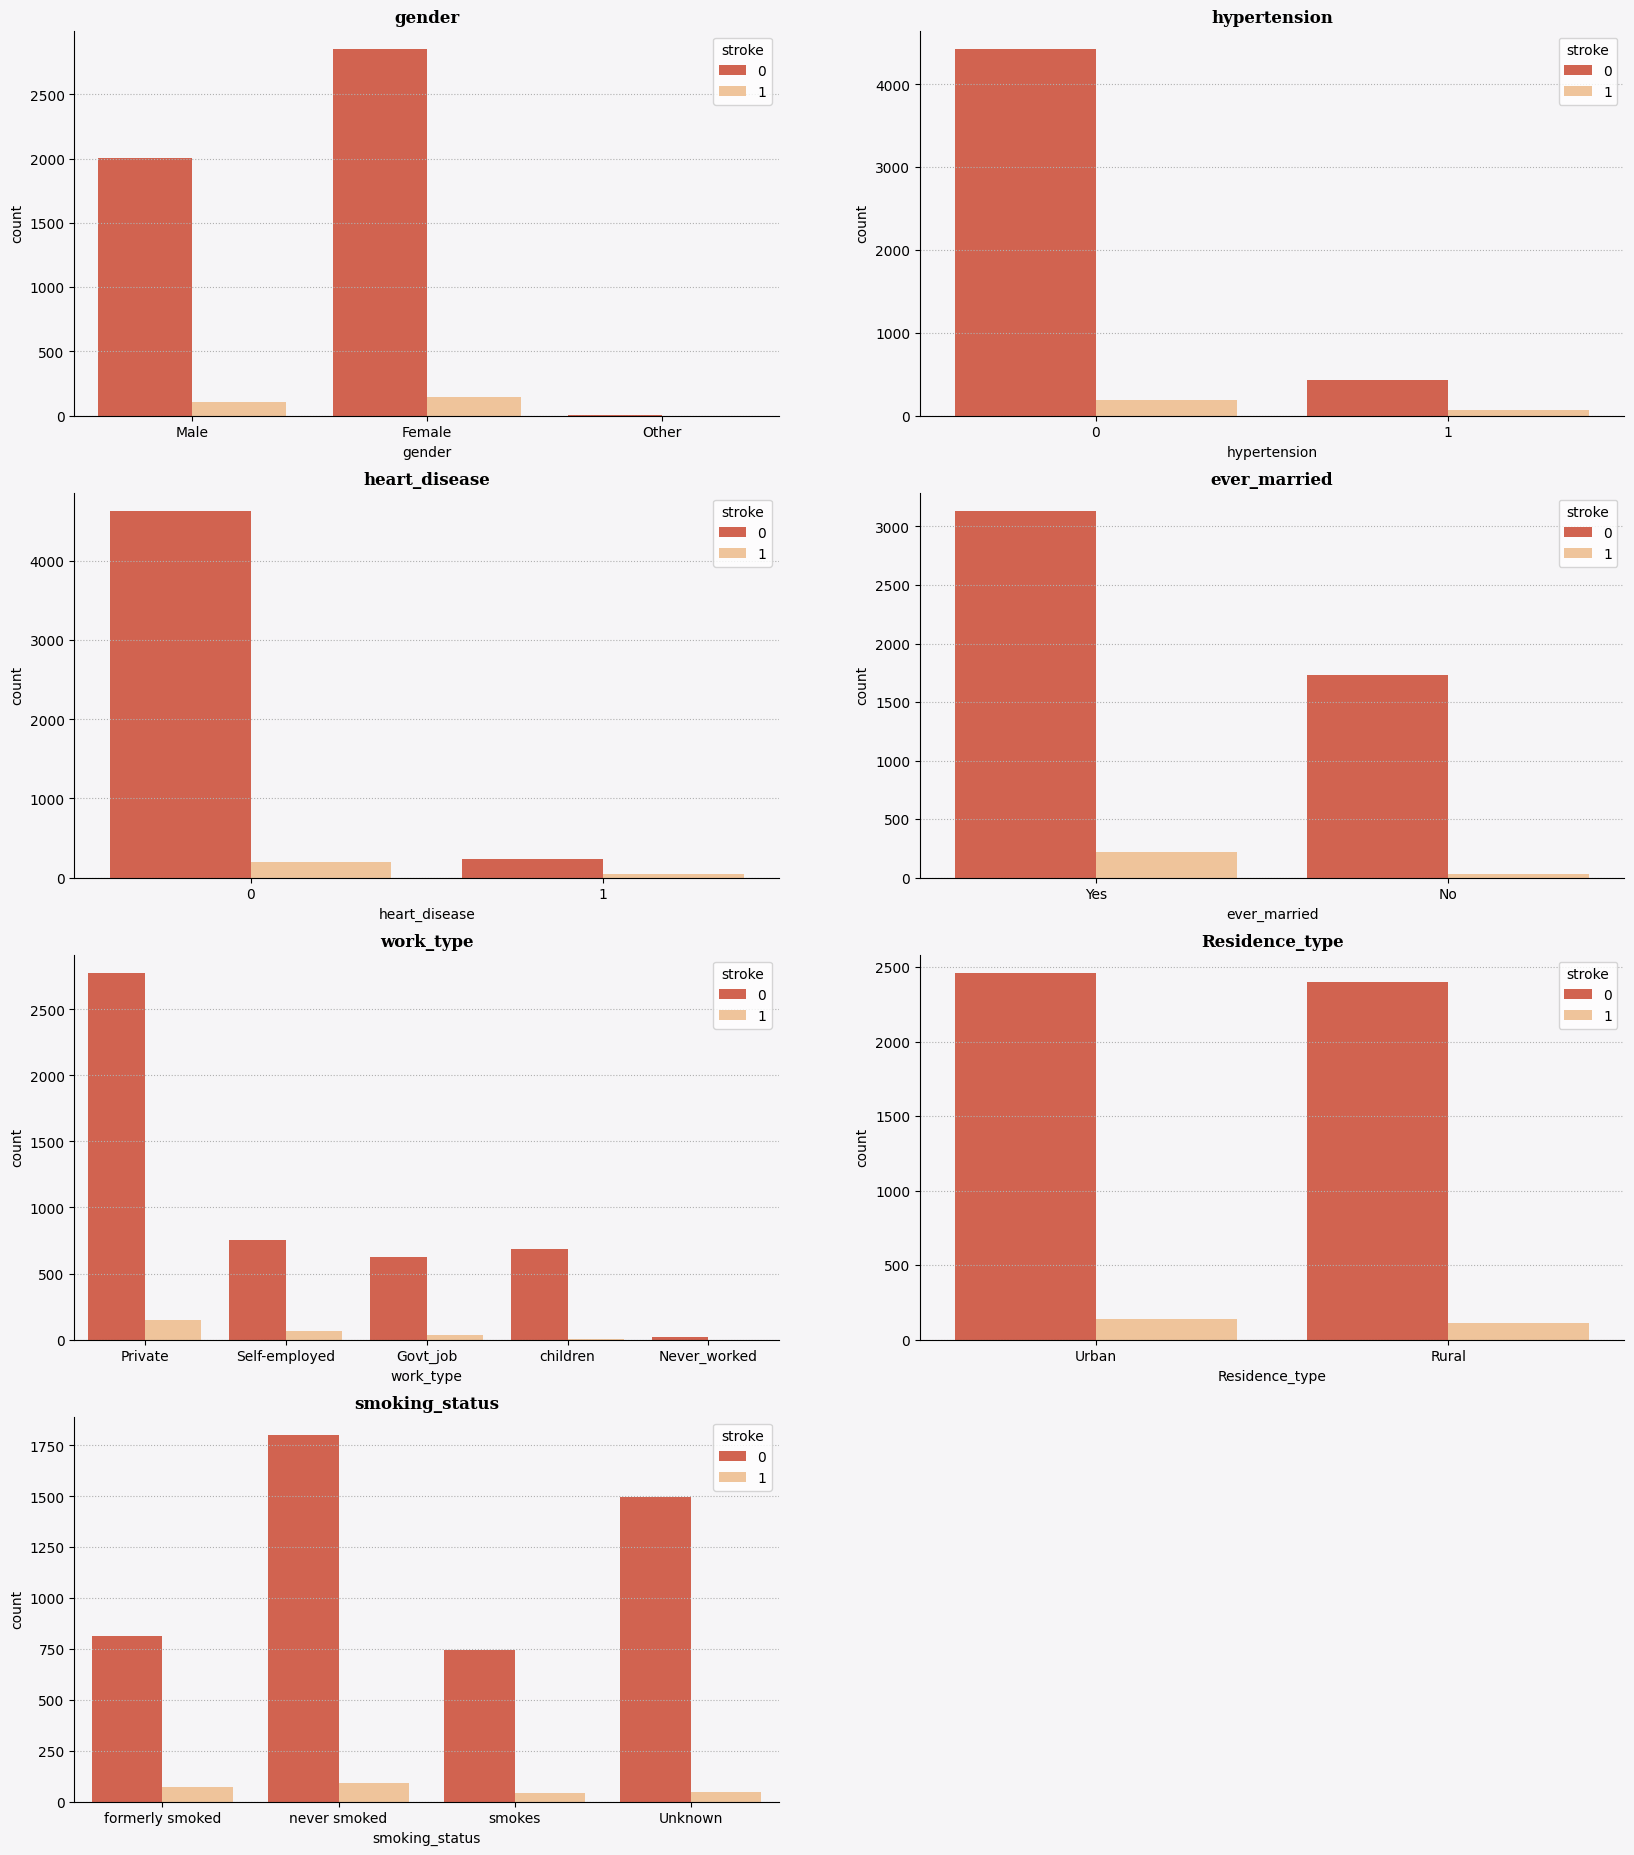

In [ ]:
data_cat=data[['gender', 'hypertension', 'heart_disease', 'ever_married','work_type', 'Residence_type',
                       'smoking_status']]
fig=plt.figure(figsize=(20,23))
background_color = '#f6f5f7'
fig.patch.set_facecolor(background_color)
for indx,val in enumerate(data_cat.columns):
    ax=plt.subplot(4,2,indx+1)
    ax.set_facecolor(background_color)
    ax.set_title(val,fontweight='bold',fontfamily='serif')
    for i in ['top','right']:
        ax.spines[i].set_visible(False)
    ax.grid(linestyle=':',axis='y')
    sns.countplot(x=val, data=data, palette='OrRd_r', hue='stroke')

Text(-0.7, 100, 'Smoking Status and Stroke')

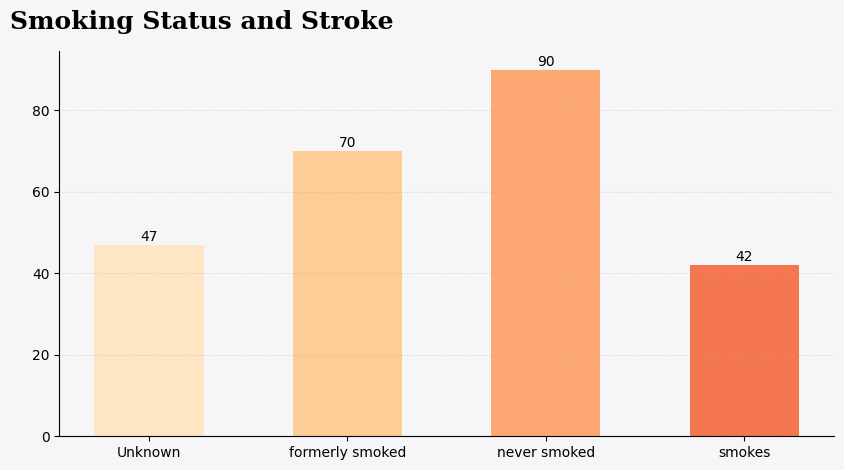

In [ ]:
# Smoking Type and Stroke
pd_stroke = pd.pivot_table(data=data[data['stroke']==1],index=data['smoking_status'],values='stroke',aggfunc='count').reset_index()
fig,ax=plt.subplots(1,1,figsize=(10,5))
background_color = '#f6f5f7'
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)
ax.bar(pd_stroke['smoking_status'],pd_stroke['stroke'],width=0.55,linewidth=0.7,color=sns.color_palette('OrRd'))
for idx,val in enumerate(pd_stroke['stroke']):
    ax.text(idx,val+1,round(val,1),horizontalalignment='center')
ax.grid(linestyle=':',axis='y',alpha=0.5)
for i in ['top','right']:
    ax.spines[i].set_visible(False)
plt.text(-0.7,100,'Smoking Status and Stroke',fontsize=18,fontweight='bold',fontfamily='serif')

Text(-0.7, 250, 'Marrital Status and Stroke')

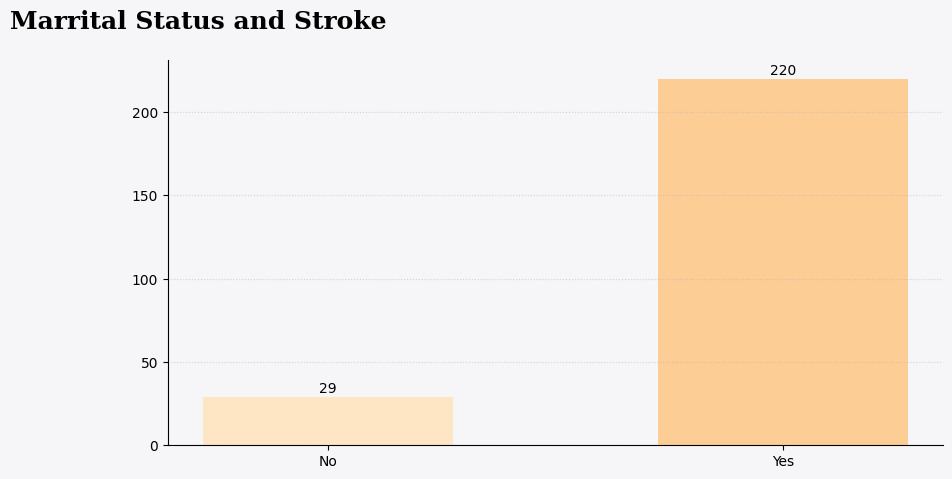

In [ ]:
# Marrital Status and Stroke
pd_stroke = pd.pivot_table(data=data[data['stroke']==1],index=data['ever_married'],values='stroke',aggfunc='count').reset_index()
fig,ax=plt.subplots(1,1,figsize=(10,5))
background_color = '#f6f5f7'
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)
ax.bar(pd_stroke['ever_married'],pd_stroke['stroke'],width=0.55,linewidth=0.7,color=sns.color_palette('OrRd'))
for an in pd_stroke.index:
    ax.annotate(pd_stroke['stroke'][an],xy=(pd_stroke['ever_married'][an],pd_stroke['stroke'][an]+5),va='center',ha='center')
ax.grid(linestyle=':',axis='y',alpha=0.5)
for i in ['top','right']:
    ax.spines[i].set_visible(False)
plt.text(-0.7,250,'Marrital Status and Stroke',fontsize=18,fontweight='bold',fontfamily='serif')

Text(-0.7, 170, 'Work Type and Stroke')

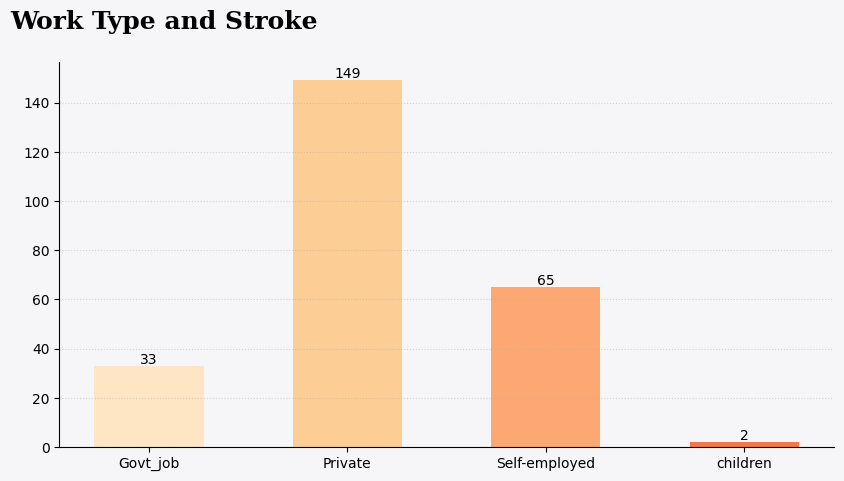

In [ ]:
# Work Type and Stroke
pd_stroke = pd.pivot_table(data=data[data['stroke']==1],index=data['work_type'],values='stroke',aggfunc='count').reset_index()
fig,ax=plt.subplots(1,1,figsize=(10,5))
background_color = '#f6f5f7'
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)
ax.bar(pd_stroke['work_type'],pd_stroke['stroke'],width=0.55,linewidth=0.7,color=sns.color_palette('OrRd'))
for idx,val in enumerate(pd_stroke['stroke']):
    ax.text(idx,val+1,round(val,1),horizontalalignment='center')
ax.grid(linestyle=':',axis='y',alpha=0.5)
for i in ['top','right']:
    ax.spines[i].set_visible(False)
plt.text(-0.7,170,'Work Type and Stroke',fontsize=18,fontweight='bold',fontfamily='serif')

Text(-0.7, 210, 'Hypertension and Stroke')

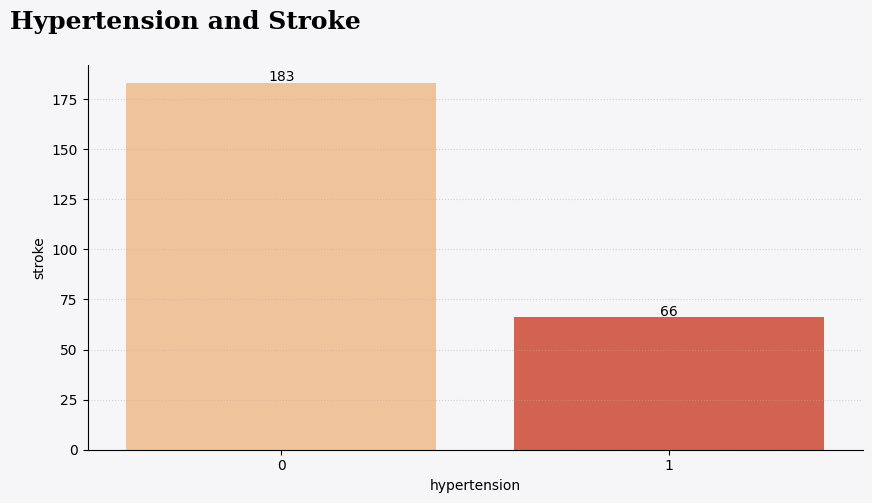

In [ ]:
# Hypertension and Stroke
pd_stroke = pd.pivot_table(data=data[data['stroke']==1],index=data['hypertension'],values='stroke',aggfunc='count').reset_index()
fig,ax=plt.subplots(1,1,figsize=(10,5))
background_color = '#f6f5f7'
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)
sns.barplot(ax=ax,x=pd_stroke['hypertension'],y=pd_stroke['stroke'],palette='OrRd')
for idx,val in enumerate(pd_stroke['stroke']):
    ax.text(idx,val+1,round(val,1),horizontalalignment='center')
ax.grid(linestyle=':',axis='y',alpha=0.5)
for i in ['top','right']:
    ax.spines[i].set_visible(False)
plt.text(-0.7,210,'Hypertension and Stroke',fontsize=18,fontweight='bold',fontfamily='serif')

Text(-0.7, 220, 'Heart Disease and Stroke')

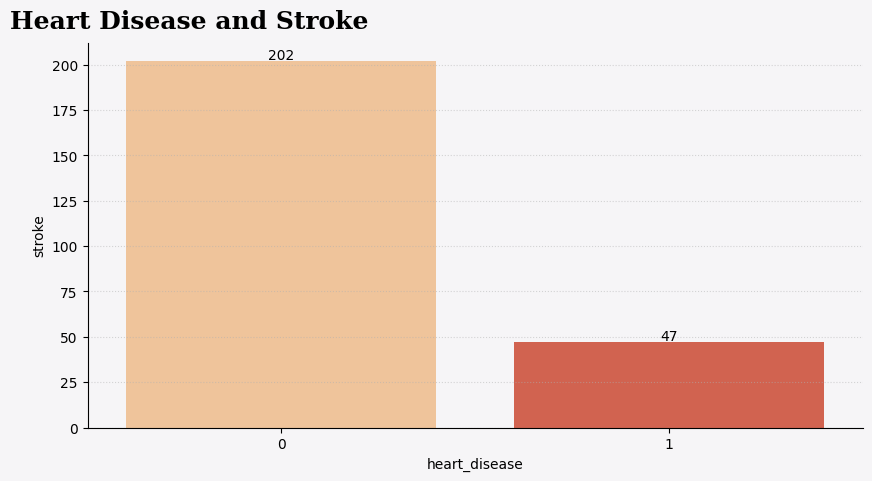

In [ ]:
# Heart Disease and Stroke
pd_stroke = pd.pivot_table(data=data[data['stroke']==1],index=data['heart_disease'],values='stroke',aggfunc='count').reset_index()
fig,ax=plt.subplots(1,1,figsize=(10,5))
background_color = '#f6f5f7'
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color)
sns.barplot(ax=ax,x=pd_stroke['heart_disease'],y=pd_stroke['stroke'],palette='OrRd')
for idx,val in enumerate(pd_stroke['stroke']):
    ax.text(idx,val+1,round(val,1),horizontalalignment='center')
ax.grid(linestyle=':',axis='y',alpha=0.5)
for i in ['top','right']:
    ax.spines[i].set_visible(False)
plt.text(-0.7,220,'Heart Disease and Stroke',fontsize=18,fontweight='bold',fontfamily='serif')

Text(-1.7, 1.1, 'Heatmap of Data')

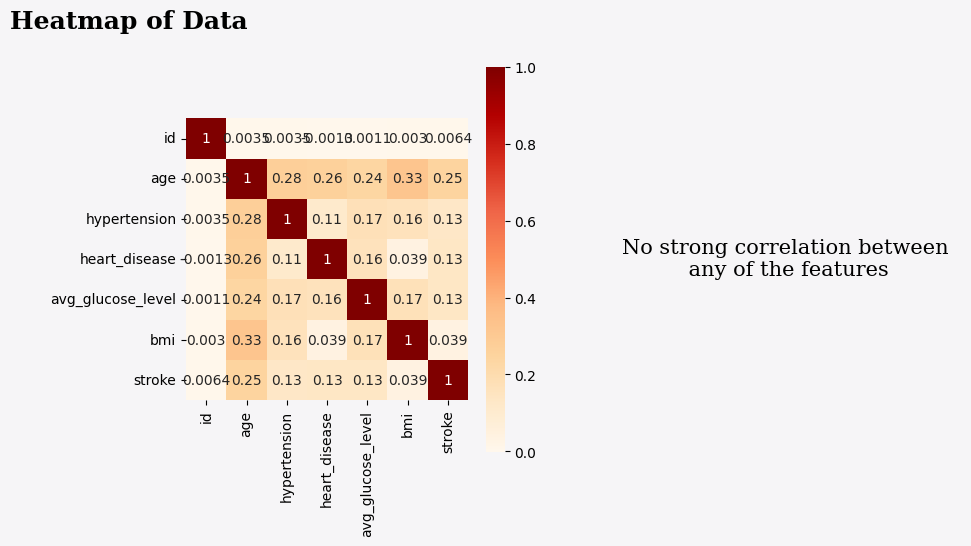

In [ ]:
fig=plt.figure(figsize=(10,5),dpi=100)
gs=fig.add_gridspec(1,2)
# adding subplots
ax0=fig.add_subplot(gs[0,0])
ax1=fig.add_subplot(gs[0,1])
axes=[ax0,ax1]
background_color = '#f6f5f7'
# changing background color of our plots
for i in axes:
    i.set_facecolor(background_color)
# changing the figure background color
fig.patch.set_facecolor(background_color)
# heatmap of numerical data
corrmat = data.select_dtypes(include=np.number).corr()
sns.heatmap(ax=ax0,data=corrmat,annot=True, cmap="OrRd",square=True)
ax1.text(0.5,0.5,'No strong correlation between\n any of the features',horizontalalignment = 'center',verticalalignment = 'center',fontsize = 15,fontfamily='serif')
ax1.spines["bottom"].set_visible(False)
ax1.spines["left"].set_visible(False)
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.tick_params(left=False, bottom=False)
for i in ["top","right","bottom","left"]:
    ax1.spines[i].set_visible(False)
plt.text(-1.7,1.1,'Heatmap of Data',fontsize=18,fontweight='bold',fontfamily='serif')

In [ ]:
# Convert Marrital Status, Residence and Gender into 0's and 1's
data['gender']=data['gender'].apply(lambda x : 1 if x=='Male' else 0)
data["Residence_type"] = data["Residence_type"].apply(lambda x: 1 if x=="Urban" else 0)
data["ever_married"] = data["ever_married"].apply(lambda x: 1 if x=="Yes" else 0)
# Removing the observations that have smoking type unknown.
data=data[data['smoking_status']!='Unknown']

In [ ]:
# One Hot encoding smoking_status, work_type
data_dummies = data[['smoking_status','work_type']]
data_dummies=pd.get_dummies(data_dummies)
data.drop(columns=['smoking_status','work_type'],inplace=True)

In [ ]:
data_stroke=data['stroke']
data.drop(columns=['stroke'],inplace=True)
data=data.merge(data_dummies,left_index=True, right_index=True,how='left')

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(data,data_stroke,test_size=0.25,random_state=0)

In [ ]:
# Standardizing our training and testing data.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=4)
x_train, y_train = sm.fit_resample(x_train, y_train.ravel())

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

In [ ]:
#https://towardsdatascience.com/model-evaluation-techniques-for-classification-models-eac30092c38b
def Model(model):
    model.fit(x_train,y_train)
    score = model.score(x_test, y_test)
    model_train_score = model.score(x_train, y_train)
    model_test_score = model.score(x_test, y_test)
    prediction = model.predict(x_test)
    cm = confusion_matrix(y_test,prediction)
    print('Testing Score \n',score)
    ConfusionMatrixDisplay.from_estimator(model,x_test,y_test,cmap="OrRd")
    RocCurveDisplay.from_estimator(model, x_test, y_test)

Testing Score 
 0.7387892376681614


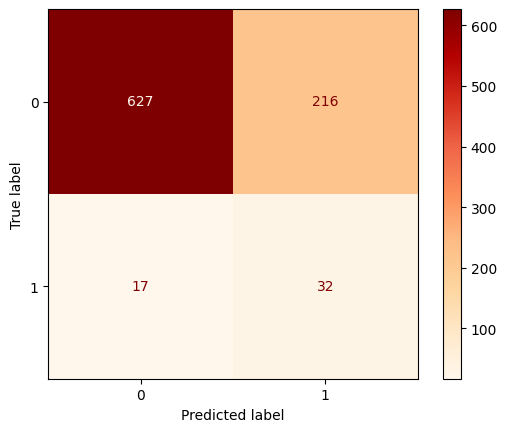

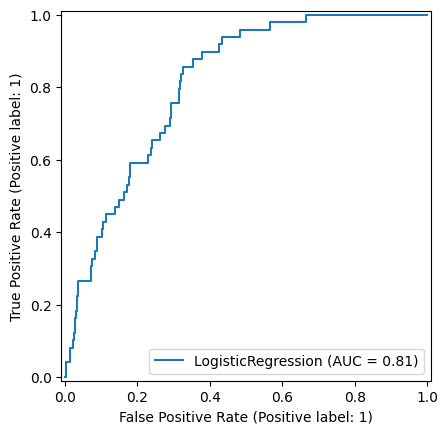

In [ ]:
# Logistic Regression
from sklearn.metrics import RocCurveDisplay
lg_reg=LogisticRegression()
Model(lg_reg)